In [51]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from smyleutils import averaging_utils as avg
from smyleutils import qboplot_utils as qbo
from smyleutils import colorbar_utils as cbars
from smyleutils import linfit_utils as linfit

In [131]:
plotpath="/glade/campaign/cgd/cas/islas/python_plots/NCAR_CW3E_SMYLE/FIGURES/SUPP/"

### Read in the zonal wind and temperature data for each initialization

In [3]:
basepath="/glade/campaign/cgd/cas/islas/python_savs/NCAR_CW3E_SMYLE/DATA_SORT/Uzm/"
high_nov=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E-L83_day_init11.nc')
low_nov=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E_day_init11.nc')
era5_nov=xr.open_dataset(basepath+'Uzm_ERA5_day_init11.nc')

high_sep=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E-L83_day_init09.nc')
low_sep=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E_day_init09.nc')
era5_sep=xr.open_dataset(basepath+'Uzm_ERA5_day_init09.nc')

high_feb=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E-L83_day_init02.nc')
low_feb=xr.open_dataset(basepath+'Uzm_BSMYLE-CW3E_day_init02.nc')
era5_feb=xr.open_dataset(basepath+'Uzm_ERA5_day_init02.nc')

basepath="/glade/campaign/cgd/cas/islas/python_savs/NCAR_CW3E_SMYLE/DATA_SORT/Tzm/"
tzm_high_nov=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E-L83_day_init11.nc')
tzm_low_nov=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E_day_init11.nc')
tzm_era5_nov=xr.open_dataset(basepath+'Tzm_ERA5_day_init11.nc')

tzm_high_sep=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E-L83_day_init09.nc')
tzm_low_sep=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E_day_init09.nc')
tzm_era5_sep=xr.open_dataset(basepath+'Tzm_ERA5_day_init09.nc')

tzm_high_feb=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E-L83_day_init02.nc')
tzm_low_feb=xr.open_dataset(basepath+'Tzm_BSMYLE-CW3E_day_init02.nc')
tzm_era5_feb=xr.open_dataset(basepath+'Tzm_ERA5_day_init02.nc')

### Read in the ERSSTv5 SST

In [6]:
basepath="/glade/campaign/cgd/cas/islas/python_savs/NCAR_CW3E_SMYLE/DATA_SORT/SST/"
sst_nov = xr.open_dataset(basepath+'SST_ERSSTv5_mon_init11.nc')
sst_sep = xr.open_dataset(basepath+'SST_ERSSTv5_mon_init09.nc')
sst_feb = xr.open_dataset(basepath+'SST_ERSSTv5_mon_init02.nc')

### Select out ony the first 6 months

In [7]:
startdate=high_nov.time.isel(time=0).values ; enddate=high_nov.time.isel(time=high_nov.time.size-1).values
high_nov = high_nov.sel(time=slice(startdate,enddate)).Uzm
low_nov = low_nov.sel(time=slice(startdate,enddate)).Uzm
era5_nov = era5_nov.sel(time=slice(startdate,enddate)).Uzm

startdate=high_sep.time.isel(time=0).values ; enddate=high_sep.time.isel(time=high_sep.time.size-1).values
high_sep = high_sep.sel(time=slice(startdate,enddate)).Uzm
low_sep = low_sep.sel(time=slice(startdate,enddate)).Uzm
era5_sep = era5_sep.sel(time=slice(startdate,enddate)).Uzm

startdate=high_feb.time.isel(time=0).values ; enddate=high_feb.time.isel(time=high_feb.time.size-1).values
high_feb = high_feb.sel(time=slice(startdate,enddate)).Uzm
low_feb = low_feb.sel(time=slice(startdate,enddate)).Uzm
era5_feb = era5_feb.sel(time=slice(startdate,enddate)).Uzm

startdate=high_nov.time.isel(time=0).values ; enddate=high_nov.time.isel(time=high_nov.time.size-1).values
tzm_high_nov = tzm_high_nov.sel(time=slice(startdate, enddate)).Tzm
tzm_low_nov = tzm_low_nov.sel(time=slice(startdate, enddate)).Tzm
tzm_era5_nov = tzm_era5_nov.sel(time=slice(startdate, enddate)).Tzm

startdate=high_sep.time.isel(time=0).values ; enddate=high_sep.time.isel(time=high_sep.time.size-1).values
tzm_high_sep = tzm_high_sep.sel(time=slice(startdate, enddate)).Tzm
tzm_low_sep = tzm_low_sep.sel(time=slice(startdate, enddate)).Tzm
tzm_era5_sep = tzm_era5_sep.sel(time=slice(startdate, enddate)).Tzm

startdate=high_feb.time.isel(time=0).values ; enddate=high_feb.time.isel(time=high_feb.time.size-1).values
tzm_high_feb = tzm_high_feb.sel(time=slice(startdate, enddate)).Tzm
tzm_low_feb = tzm_low_feb.sel(time=slice(startdate, enddate)).Tzm
tzm_era5_feb = tzm_era5_feb.sel(time=slice(startdate, enddate)).Tzm

### Average over the tropics

In [65]:
high_nov_tr = avg.cosweightlat(high_nov,-5,5).load()
low_nov_tr = avg.cosweightlat(low_nov,-5,5).load()
era5_nov_tr = avg.cosweightlat(era5_nov,-5,5).load()

high_sep_tr = avg.cosweightlat(high_sep,-5,5).load()
low_sep_tr = avg.cosweightlat(low_sep,-5,5).load()
era5_sep_tr = avg.cosweightlat(era5_sep,-5,5).load()

high_feb_tr = avg.cosweightlat(high_feb,-5,5).load()
low_feb_tr = avg.cosweightlat(low_feb,-5,5).load()
era5_feb_tr = avg.cosweightlat(era5_feb,-5,5).load()

tzm_high_nov_tr = avg.cosweightlat(tzm_high_nov,-5,5).load()
tzm_low_nov_tr = avg.cosweightlat(tzm_low_nov,-5,5).load()
tzm_era5_nov_tr = avg.cosweightlat(tzm_era5_nov,-5,5).load()

tzm_high_sep_tr = avg.cosweightlat(tzm_high_sep,-5,5).load()
tzm_low_sep_tr = avg.cosweightlat(tzm_low_sep,-5,5).load()
tzm_era5_sep_tr = avg.cosweightlat(tzm_era5_sep,-5,5).load()

tzm_high_feb_tr = avg.cosweightlat(tzm_high_feb,-5,5).load()
tzm_low_feb_tr = avg.cosweightlat(tzm_low_feb,-5,5).load()
tzm_era5_feb_tr = avg.cosweightlat(tzm_era5_feb,-5,5).load()

DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat
DataArrayWeighted with weights along dimensions: lat


### Compute Nino3.4

In [66]:
nino34_nov = avg.cosweightlonlat(sst_nov, 210, 270, -5, 5)
nino34_sep = avg.cosweightlonlat(sst_sep, 210, 270, -5, 5)
nino34_feb = avg.cosweightlonlat(sst_feb, 210, 270, -5, 5)

### Interpolate to the ERA5 pressure levels

In [67]:
high_nov_tr_interp = high_nov_tr.interp(ilev=era5_nov.level)
low_nov_tr_interp = low_nov_tr.interp(ilev=era5_nov.level)

high_sep_tr_interp = high_sep_tr.interp(ilev=era5_nov.level)
low_sep_tr_interp = low_sep_tr.interp(ilev=era5_nov.level)

high_feb_tr_interp = high_feb_tr.interp(ilev=era5_nov.level)
low_feb_tr_interp = low_feb_tr.interp(ilev=era5_nov.level)

tzm_high_nov_tr_interp = tzm_high_nov_tr.interp(ilev=era5_nov.level)
tzm_low_nov_tr_interp = tzm_low_nov_tr.interp(ilev=era5_nov.level)

tzm_high_sep_tr_interp = tzm_high_sep_tr.interp(ilev=era5_nov.level)
tzm_low_sep_tr_interp = tzm_low_sep_tr.interp(ilev=era5_nov.level)

tzm_high_feb_tr_interp = tzm_high_feb_tr.interp(ilev=era5_nov.level)
tzm_low_feb_tr_interp = tzm_low_feb_tr.interp(ilev=era5_nov.level)

### Calculate the ensemble mean

In [68]:
high_nov_tr_interpm = high_nov_tr_interp.mean('M')
low_nov_tr_interpm = low_nov_tr_interp.mean('M')

high_sep_tr_interpm = high_sep_tr_interp.mean('M')
low_sep_tr_interpm = low_sep_tr_interp.mean('M')

high_feb_tr_interpm = high_feb_tr_interp.mean('M')
low_feb_tr_interpm = low_feb_tr_interp.mean('M')

tzm_high_nov_tr_interpm = tzm_high_nov_tr_interp.mean('M')
tzm_low_nov_tr_interpm = tzm_low_nov_tr_interp.mean('M')

tzm_high_sep_tr_interpm = tzm_high_sep_tr_interp.mean('M')
tzm_low_sep_tr_interpm = tzm_low_sep_tr_interp.mean('M')

tzm_high_feb_tr_interpm = tzm_high_feb_tr_interp.mean('M')
tzm_low_feb_tr_interpm = tzm_low_feb_tr_interp.mean('M')

### Calculate the lead dependent climatology

In [69]:
era5_nov_tr_clim = era5_nov_tr.mean('init_year')
high_nov_tr_interpm_clim = high_nov_tr_interpm.mean('init_year')
low_nov_tr_interpm_clim = low_nov_tr_interpm.mean('init_year')

era5_sep_tr_clim = era5_sep_tr.mean('init_year')
high_sep_tr_interpm_clim = high_sep_tr_interpm.mean('init_year')
low_sep_tr_interpm_clim = low_sep_tr_interpm.mean('init_year')

era5_feb_tr_clim = era5_feb_tr.mean('init_year')
high_feb_tr_interpm_clim = high_feb_tr_interpm.mean('init_year')
low_feb_tr_interpm_clim = low_feb_tr_interpm.mean('init_year')

tzm_era5_nov_tr_clim = tzm_era5_nov_tr.mean('init_year')
tzm_high_nov_tr_interpm_clim = tzm_high_nov_tr_interpm.mean('init_year')
tzm_low_nov_tr_interpm_clim = tzm_low_nov_tr_interpm.mean('init_year')

tzm_era5_sep_tr_clim = tzm_era5_sep_tr.mean('init_year')
tzm_high_sep_tr_interpm_clim = tzm_high_sep_tr_interpm.mean('init_year')
tzm_low_sep_tr_interpm_clim = tzm_low_sep_tr_interpm.mean('init_year')

tzm_era5_feb_tr_clim = tzm_era5_feb_tr.mean('init_year')
tzm_high_feb_tr_interpm_clim = tzm_high_feb_tr_interpm.mean('init_year')
tzm_low_feb_tr_interpm_clim = tzm_low_feb_tr_interpm.mean('init_year')

nino34_nov_clim = nino34_nov.mean('init_year')
nino34_sep_clim = nino34_sep.mean('init_year')
nino34_feb_clim = nino34_feb.mean('init_year')

### Remove the lead dependent climatology

In [70]:
era5_nov_tr = era5_nov_tr - era5_nov_tr_clim
high_nov_tr_interp = high_nov_tr_interp - high_nov_tr_interpm_clim
low_nov_tr_interp = low_nov_tr_interp - low_nov_tr_interpm_clim
high_nov_tr_interpm = high_nov_tr_interpm - high_nov_tr_interpm_clim
low_nov_tr_interpm = low_nov_tr_interpm - low_nov_tr_interpm_clim

era5_sep_tr = era5_sep_tr - era5_sep_tr_clim
high_sep_tr_interp = high_sep_tr_interp - high_sep_tr_interpm_clim
low_sep_tr_interp = low_sep_tr_interp - low_sep_tr_interpm_clim
high_sep_tr_interpm = high_sep_tr_interpm - high_sep_tr_interpm_clim
low_sep_tr_interpm = low_sep_tr_interpm - low_sep_tr_interpm_clim

era5_feb_tr = era5_feb_tr - era5_feb_tr_clim
high_feb_tr_interp = high_feb_tr_interp - high_feb_tr_interpm_clim
low_feb_tr_interp = low_feb_tr_interp - low_feb_tr_interpm_clim
high_feb_tr_interpm = high_feb_tr_interpm - high_feb_tr_interpm_clim
low_feb_tr_interpm = low_feb_tr_interpm - low_feb_tr_interpm_clim


tzm_era5_nov_tr = tzm_era5_nov_tr - tzm_era5_nov_tr_clim
tzm_high_nov_tr_interp = tzm_high_nov_tr_interp - tzm_high_nov_tr_interpm_clim
tzm_low_nov_tr_interp = tzm_low_nov_tr_interp - tzm_low_nov_tr_interpm_clim
tzm_high_nov_tr_interpm = tzm_high_nov_tr_interpm - tzm_high_nov_tr_interpm_clim
tzm_low_nov_tr_interpm = tzm_low_nov_tr_interpm - tzm_low_nov_tr_interpm_clim

tzm_era5_sep_tr = tzm_era5_sep_tr - tzm_era5_sep_tr_clim
tzm_high_sep_tr_interp = tzm_high_sep_tr_interp - tzm_high_sep_tr_interpm_clim
tzm_low_sep_tr_interp = tzm_low_sep_tr_interp - tzm_low_sep_tr_interpm_clim
tzm_high_sep_tr_interpm = tzm_high_sep_tr_interpm - tzm_high_sep_tr_interpm_clim
tzm_low_sep_tr_interpm = tzm_low_sep_tr_interpm - tzm_low_sep_tr_interpm_clim

tzm_era5_feb_tr = tzm_era5_feb_tr - tzm_era5_feb_tr_clim
tzm_high_feb_tr_interp = tzm_high_feb_tr_interp - tzm_high_feb_tr_interpm_clim
tzm_low_feb_tr_interp = tzm_low_feb_tr_interp - tzm_low_feb_tr_interpm_clim
tzm_high_feb_tr_interpm = tzm_high_feb_tr_interpm - tzm_high_feb_tr_interpm_clim
tzm_low_feb_tr_interpm = tzm_low_feb_tr_interpm - tzm_low_feb_tr_interpm_clim

nino34_nov = nino34_nov - nino34_nov_clim
nino34_sep = nino34_sep - nino34_sep_clim
nino34_feb = nino34_feb - nino34_feb_clim

In [71]:
era5_feb_tr = era5_feb_tr[:,-60:,:].mean('time')
era5_sep_tr = era5_sep_tr[:,-60:,:].mean('time')
era5_nov_tr = era5_nov_tr[:,-60:,:].mean('time')

tzm_era5_feb_tr = tzm_era5_feb_tr[:,-60:,:].mean('time')
tzm_era5_sep_tr = tzm_era5_sep_tr[:,-60:,:].mean('time')
tzm_era5_nov_tr = tzm_era5_nov_tr[:,-60:,:].mean('time')

high_feb_tr_interp = high_feb_tr_interp[:,:,-60:,:].mean('time')
high_sep_tr_interp = high_sep_tr_interp[:,:,-60:,:].mean('time')
high_nov_tr_interp = high_nov_tr_interp[:,:,-60:,:].mean('time')

tzm_high_feb_tr_interp = tzm_high_feb_tr_interp[:,:,-60:,:].mean('time')
tzm_high_sep_tr_interp = tzm_high_sep_tr_interp[:,:,-60:,:].mean('time')
tzm_high_nov_tr_interp = tzm_high_nov_tr_interp[:,:,-60:,:].mean('time')

low_feb_tr_interp = low_feb_tr_interp[:,:,-60:,:].mean('time')
low_sep_tr_interp = low_sep_tr_interp[:,:,-60:,:].mean('time')
low_nov_tr_interp = low_nov_tr_interp[:,:,-60:,:].mean('time')

tzm_low_feb_tr_interp = tzm_low_feb_tr_interp[:,:,-60:,:].mean('time')
tzm_low_sep_tr_interp = tzm_low_sep_tr_interp[:,:,-60:,:].mean('time')
tzm_low_nov_tr_interp = tzm_low_nov_tr_interp[:,:,-60:,:].mean('time')

nino34_nov = nino34_nov.sst[:,-2:].mean('time')
nino34_sep = nino34_sep.sst[:,-2:].mean('time')
nino34_feb = nino34_feb.sst[:,-2:].mean('time')

In [75]:
tzm_era5_nov_tr_clim = tzm_era5_nov_tr_clim[-60:,:].mean('time')
tzm_era5_sep_tr_clim = tzm_era5_sep_tr_clim[-60:,:].mean('time')
tzm_era5_feb_tr_clim = tzm_era5_feb_tr_clim[-60:,:].mean('time')

In [81]:
tzm_high_nov_tr_interpm_clim = tzm_high_nov_tr_interpm_clim[-60:,:].mean('time')
tzm_high_sep_tr_interpm_clim = tzm_high_sep_tr_interpm_clim[-60:,:].mean('time')
tzm_high_feb_tr_interpm_clim = tzm_high_feb_tr_interpm_clim[-60:,:].mean('time')

tzm_low_nov_tr_interpm_clim = tzm_low_nov_tr_interpm_clim[-60:,:].mean('time')
tzm_low_sep_tr_interpm_clim = tzm_low_sep_tr_interpm_clim[-60:,:].mean('time')
tzm_low_feb_tr_interpm_clim = tzm_low_feb_tr_interpm_clim[-60:,:].mean('time')

In [ ]:
### Regress onto the QBO
b_feb_qbo=[]
b_feb_nino=[]
b_nov_qbo=[]
b_nov_nino=[]
b_sep_qbo=[]
b_sep_nino=[]

b_high_feb_qbo=[]
b_high_feb_nino=[]
b_high_nov_qbo=[]
b_high_nov_nino=[]
b_high_sep_qbo=[]
b_high_sep_nino=[]

b_low_feb_qbo=[]
b_low_feb_nino=[]
b_low_nov_qbo=[]
b_low_nov_nino=[]
b_low_sep_qbo=[]
b_low_sep_nino=[]


for ilev in np.arange(0,tzm_era5_feb_tr.level.size,1):
    print(ilev)
    a, b = linfit.linfit_xy(era5_feb_tr.sel(level=50, method='nearest'), tzm_era5_feb_tr.isel(level=ilev))
    b_feb_qbo.append(xr.DataArray(b))

    a, b = linfit.linfit_xy(nino34_feb, tzm_era5_feb_tr.isel(level=ilev))
    b_feb_nino.append(xr.DataArray(b))

    a, b = linfit.linfit_xy(era5_sep_tr.sel(level=50, method='nearest'), tzm_era5_sep_tr.isel(level=ilev))
    b_sep_qbo.append(xr.DataArray(b))

    a, b = linfit.linfit_xy(nino34_sep, tzm_era5_sep_tr.isel(level=ilev))
    b_sep_nino.append(xr.DataArray(b))

    a, b = linfit.linfit_xy(era5_nov_tr.sel(level=50, method='nearest'), tzm_era5_nov_tr.isel(level=ilev))
    b_nov_qbo.append(xr.DataArray(b))

    a, b = linfit.linfit_xy(nino34_nov, tzm_era5_nov_tr.isel(level=ilev))
    b_nov_nino.append(xr.DataArray(b))

    b_high_nov_qbo_t=[] ; b_low_nov_qbo_t=[]
    b_high_nov_nino_t=[] ; b_low_nov_nino_t=[]
    b_high_feb_qbo_t=[] ; b_low_feb_qbo_t=[]
    b_high_feb_nino_t=[] ; b_low_feb_nino_t=[]
    b_high_sep_qbo_t=[] ; b_low_sep_qbo_t=[]
    b_high_sep_nino_t=[] ; b_low_sep_nino_t=[]

    for imem in np.arange(0,tzm_high_nov_tr_interp.M.size,1):
        a, b = linfit.linfit_xy(era5_feb_tr.sel(level=50, method='nearest'), tzm_high_feb_tr_interp.isel(M=imem, level=ilev))
        b_high_feb_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_feb, tzm_high_feb_tr_interp.isel(M=imem, level=ilev))
        b_high_feb_nino_t.append(xr.DataArray(b))

        a, b = linfit.linfit_xy(era5_nov_tr.sel(level=50, method='nearest'), tzm_high_nov_tr_interp.isel(M=imem, level=ilev))
        b_high_nov_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_nov, tzm_high_nov_tr_interp.isel(M=imem, level=ilev))
        b_high_nov_nino_t.append(xr.DataArray(b))

        a, b = linfit.linfit_xy(era5_sep_tr.sel(level=50, method='nearest'), tzm_high_sep_tr_interp.isel(M=imem, level=ilev))
        b_high_sep_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_sep, tzm_high_sep_tr_interp.isel(M=imem, level=ilev))
        b_high_sep_nino_t.append(xr.DataArray(b))

        a, b = linfit.linfit_xy(era5_feb_tr.sel(level=50, method='nearest'), tzm_low_feb_tr_interp.isel(M=imem, level=ilev))
        b_low_feb_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_feb, tzm_low_feb_tr_interp.isel(M=imem, level=ilev))
        b_low_feb_nino_t.append(xr.DataArray(b))

        a, b = linfit.linfit_xy(era5_nov_tr.sel(level=50, method='nearest'), tzm_low_nov_tr_interp.isel(M=imem, level=ilev))
        b_low_nov_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_nov, tzm_low_nov_tr_interp.isel(M=imem, level=ilev))
        b_low_nov_nino_t.append(xr.DataArray(b))

        a, b = linfit.linfit_xy(era5_sep_tr.sel(level=50, method='nearest'), tzm_low_sep_tr_interp.isel(M=imem, level=ilev))
        b_low_sep_qbo_t.append(xr.DataArray(b))
        a, b = linfit.linfit_xy(nino34_sep, tzm_low_sep_tr_interp.isel(M=imem, level=ilev))
        b_low_sep_nino_t.append(xr.DataArray(b))

    
    b_high_feb_qbo.append(xr.concat(b_high_feb_qbo_t, dim='M'))
    b_high_feb_nino.append(xr.concat(b_high_feb_nino_t, dim='M'))

    b_high_nov_qbo.append(xr.concat(b_high_nov_qbo_t, dim='M'))
    b_high_nov_nino.append(xr.concat(b_high_nov_nino_t, dim='M'))

    b_high_sep_qbo.append(xr.concat(b_high_sep_qbo_t, dim='M'))
    b_high_sep_nino.append(xr.concat(b_high_sep_nino_t, dim='M'))

    b_low_feb_qbo.append(xr.concat(b_low_feb_qbo_t, dim='M'))
    b_low_feb_nino.append(xr.concat(b_low_feb_nino_t, dim='M'))

    b_low_nov_qbo.append(xr.concat(b_low_nov_qbo_t, dim='M'))
    b_low_nov_nino.append(xr.concat(b_low_nov_nino_t, dim='M'))

    b_low_sep_qbo.append(xr.concat(b_low_sep_qbo_t, dim='M'))
    b_low_sep_nino.append(xr.concat(b_low_sep_nino_t, dim='M'))

b_feb_qbo = xr.concat(b_feb_qbo, dim='lev')
b_feb_nino = xr.concat(b_feb_nino, dim='lev')
b_sep_qbo = xr.concat(b_sep_qbo, dim='lev')
b_sep_nino = xr.concat(b_sep_nino, dim='lev')
b_nov_qbo = xr.concat(b_nov_qbo, dim='lev')
b_nov_nino = xr.concat(b_nov_nino, dim='lev')

b_high_feb_qbo = xr.concat(b_high_feb_qbo, dim='lev')
b_high_feb_nino = xr.concat(b_high_feb_nino, dim='lev')
b_high_sep_qbo = xr.concat(b_high_sep_qbo, dim='lev')
b_high_sep_nino = xr.concat(b_high_sep_nino, dim='lev')
b_high_nov_qbo = xr.concat(b_high_nov_qbo, dim='lev')
b_high_nov_nino = xr.concat(b_high_nov_nino, dim='lev')

b_low_feb_qbo = xr.concat(b_low_feb_qbo, dim='lev')
b_low_feb_nino = xr.concat(b_low_feb_nino, dim='lev')
b_low_sep_qbo = xr.concat(b_low_sep_qbo, dim='lev')
b_low_sep_nino = xr.concat(b_low_sep_nino, dim='lev')
b_low_nov_qbo = xr.concat(b_low_nov_qbo, dim='lev')
b_low_nov_nino = xr.concat(b_low_nov_nino, dim='lev')

b_feb_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_feb_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_sep_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_sep_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_nov_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_nov_nino['lev'] = tzm_low_sep_tr_interp.level.values

b_high_feb_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_high_feb_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_high_sep_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_high_sep_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_high_nov_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_high_nov_nino['lev'] = tzm_low_sep_tr_interp.level.values

b_low_feb_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_low_feb_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_low_sep_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_low_sep_nino['lev'] = tzm_low_sep_tr_interp.level.values
b_low_nov_qbo['lev'] = tzm_low_sep_tr_interp.level.values
b_low_nov_nino['lev'] = tzm_low_sep_tr_interp.level.values



In [86]:
b_feb_qbo

<xarray.DataArray (lev: 37)>
array([ 0.11404064, -0.0376452 ,  0.00858592,  0.03490679,  0.02702456,
       -0.00324986,  0.01708911,  0.04103447,  0.07713156,  0.10877076,
        0.10937509,  0.09008064,  0.09442365,  0.00679617, -0.08514656,
       -0.15506087, -0.19429349, -0.22725951, -0.24506488, -0.22417919,
       -0.18284278, -0.1389754 , -0.16654255, -0.22577405, -0.0719118 ,
        0.02982072, -0.03223587, -0.04693291, -0.03935901, -0.00934639,
        0.05560606,  0.16554328,  0.28011509,  0.38556463,  0.48252852,
        0.55650279,  0.5926931 ])
Coordinates:
  * lev      (lev) float64 1.0 2.0 3.0 5.0 7.0 ... 900.0 925.0 950.0 975.0 1e+03

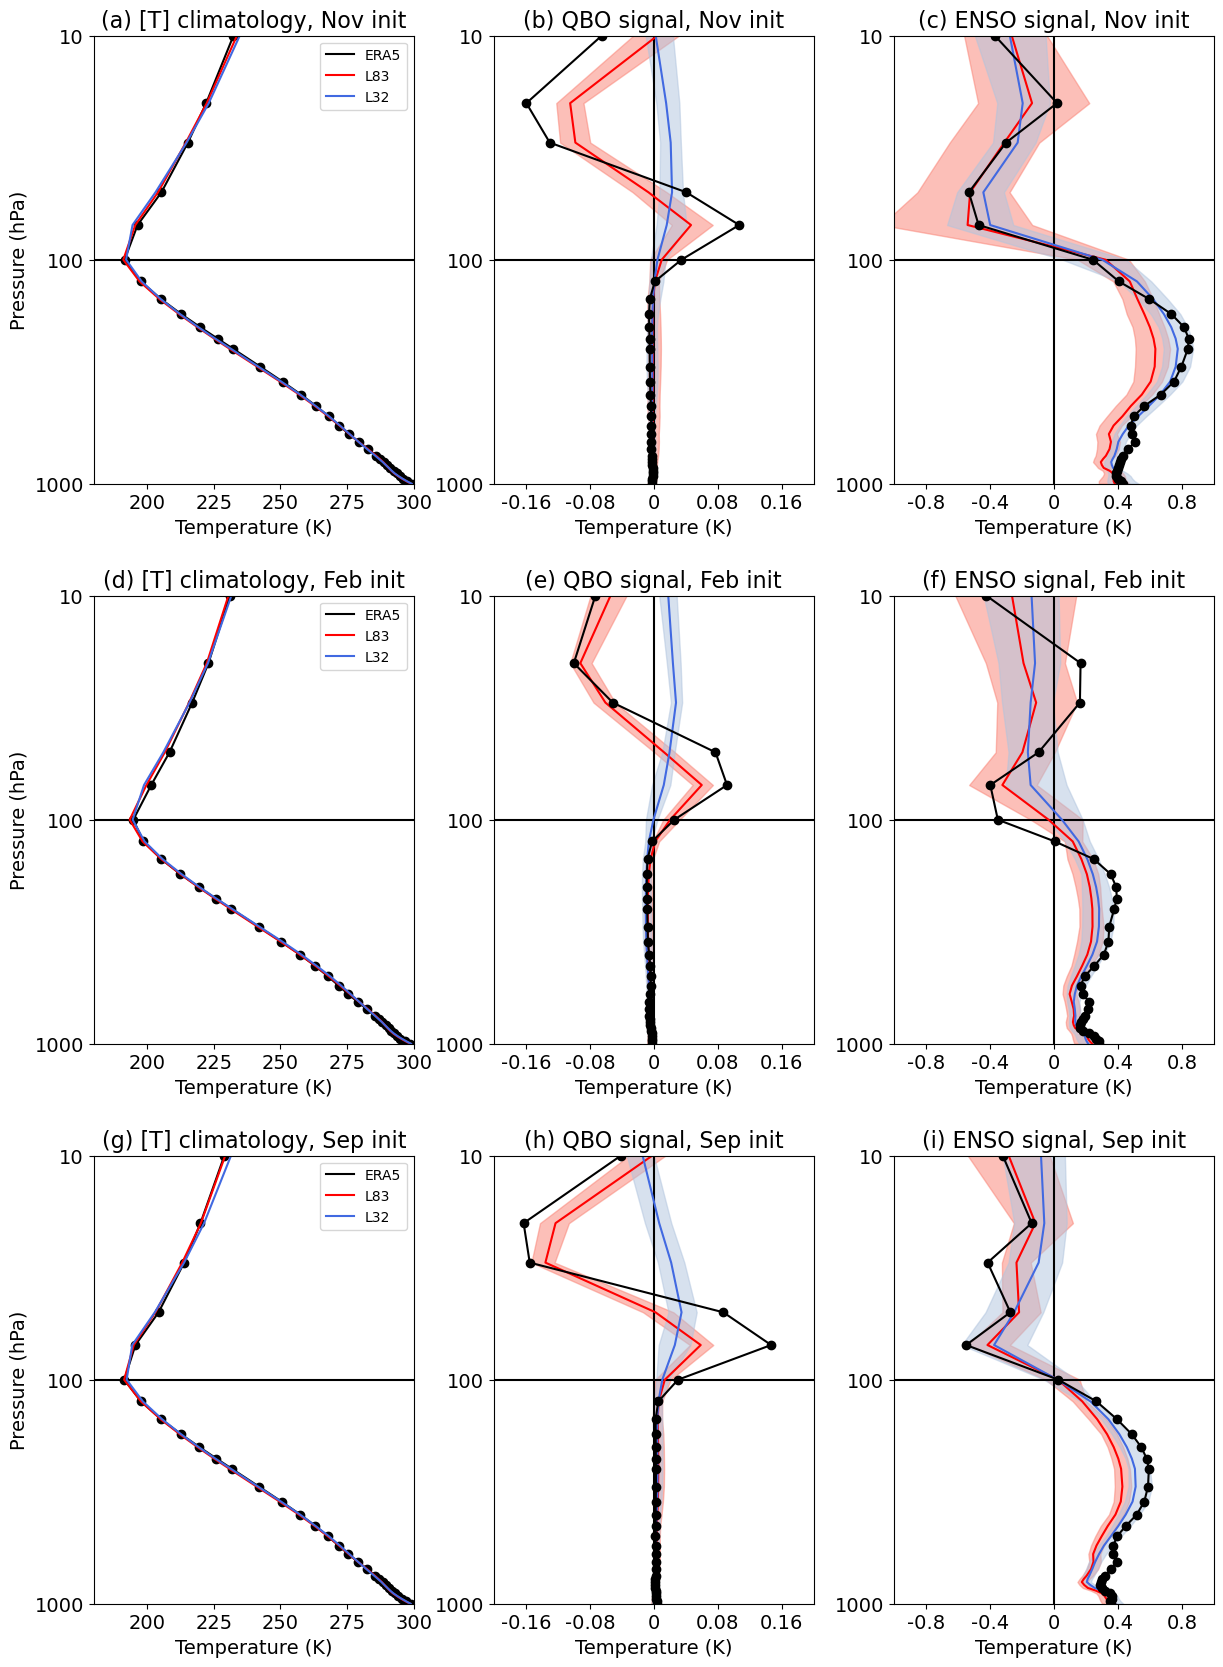

In [135]:
fig  = plt.figure(figsize=(16,16))

#----Nov initialization
#---------------Climatology
ax = fig.add_axes([0.05,0.72,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_ylabel('Pressure (hPa)', fontsize=14)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_title('(a) [T] climatology, Nov init', fontsize=16)
ax.set_xlim(180,300)
ax.set_xticks([200,225,250,275,300])
ax.set_xticklabels(['200','225','250','275','300'], fontsize=14)
ax.plot([180,300],[-np.log10(100),-np.log10(100)], color='black')

ax.plot(tzm_era5_nov_tr_clim, -np.log10(tzm_era5_nov_tr_clim.level), "o", color='black')
ax.plot(tzm_era5_nov_tr_clim, -np.log10(tzm_era5_nov_tr_clim.level), color='black', label='ERA5')
ax.plot(tzm_high_nov_tr_interpm_clim, -np.log10(tzm_era5_nov_tr_clim.level), color='red', label='L83')
ax.plot(tzm_low_nov_tr_interpm_clim, -np.log10(tzm_era5_nov_tr_clim.level), color='royalblue', label='L32')
ax.legend(loc='upper right')

#---------------Regression onto the QBO
ax = fig.add_axes([0.3,0.72,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(b) QBO signal, Nov init', fontsize=16)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_xticks([-0.16,-0.08,0,0.08,0.16])
ax.set_xticklabels(['-0.16','-0.08','0','0.08','0.16'], fontsize=14)
ax.set_xlim(-0.2,0.2)
ax.plot([-0.2,0.2],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')

ax.fill_betweenx(-np.log10(b_high_nov_qbo.lev), b_high_nov_qbo.min('M'), b_high_nov_qbo.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_nov_qbo.mean('M'), -np.log10(b_high_nov_qbo.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_nov_qbo.lev), b_low_nov_qbo.min('M'), b_low_nov_qbo.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_nov_qbo.mean('M'), -np.log10(b_low_nov_qbo.lev), color='royalblue')

ax.plot(b_nov_qbo, -np.log10(b_nov_nino.lev), "o", color='black')
ax.plot(b_nov_qbo, -np.log10(b_nov_nino.lev), color='black', label='ERA5')

#----------------Regression onto Nino3.4
ax = fig.add_axes([0.55,0.72,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(c) ENSO signal, Nov init', fontsize=16)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_xticks([-0.8,-0.4,0,0.4,0.8])
ax.set_xticklabels(['-0.8','-0.4','0','0.4','0.8'], fontsize=14)
ax.set_xlim(-1,1)
ax.plot([-1,1],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')


ax.fill_betweenx(-np.log10(b_high_nov_nino.lev), b_high_nov_nino.min('M'), b_high_nov_nino.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_nov_nino.mean('M'), -np.log10(b_high_nov_nino.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_nov_nino.lev), b_low_nov_nino.min('M'), b_low_nov_nino.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_nov_nino.mean('M'), -np.log10(b_low_nov_nino.lev), color='royalblue')

ax.plot(b_nov_nino, -np.log10(b_nov_nino.lev), "o", color='black')
ax.plot(b_nov_nino, -np.log10(b_nov_nino.lev), color='black', label='ERA5')


#----Feb initialization
#---------------Climatology
ax = fig.add_axes([0.05,0.37,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_ylabel('Pressure (hPa)', fontsize=14)
ax.set_title('(d) [T] climatology, Feb init', fontsize=16)
ax.set_xlim(180,300)
ax.set_xticks([200,225,250,275,300])
ax.set_xticklabels(['200','225','250','275','300'], fontsize=14)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.plot([180,300],[-np.log10(100),-np.log10(100)],color='black')


ax.plot(tzm_era5_feb_tr_clim, -np.log10(tzm_era5_feb_tr_clim.level), "o", color='black')
ax.plot(tzm_era5_feb_tr_clim, -np.log10(tzm_era5_feb_tr_clim.level), color='black', label='ERA5')
ax.plot(tzm_high_feb_tr_interpm_clim, -np.log10(tzm_era5_feb_tr_clim.level), color='red', label='L83')
ax.plot(tzm_low_feb_tr_interpm_clim, -np.log10(tzm_era5_feb_tr_clim.level), color='royalblue', label='L32')
ax.legend(loc='upper right')

#---------------Regression onto the QBO
ax = fig.add_axes([0.3,0.37,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(e) QBO signal, Feb init', fontsize=16)
ax.set_xlim(-0.2,0.2)
ax.set_xticks([-0.16,-0.08,0,0.08,0.16])
ax.set_xticklabels(['-0.16','-0.08','0','0.08','0.16'], fontsize=14)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.plot([-0.2,0.2],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')


ax.fill_betweenx(-np.log10(b_high_feb_qbo.lev), b_high_feb_qbo.min('M'), b_high_feb_qbo.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_feb_qbo.mean('M'), -np.log10(b_high_feb_qbo.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_feb_qbo.lev), b_low_feb_qbo.min('M'), b_low_feb_qbo.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_feb_qbo.mean('M'), -np.log10(b_low_feb_qbo.lev), color='royalblue')

ax.plot(b_feb_qbo, -np.log10(b_feb_nino.lev), "o", color='black')
ax.plot(b_feb_qbo, -np.log10(b_feb_nino.lev), color='black', label='ERA5')

#----------------Regression onto Nino3.4
ax = fig.add_axes([0.55,0.37,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(f) ENSO signal, Feb init', fontsize=16)
ax.set_xlim(-1,1)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_xticks([-0.8,-0.4,0,0.4,0.8])
ax.set_xticklabels(['-0.8','-0.4','0','0.4','0.8'], fontsize=14)
ax.plot([-1,1],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')


ax.fill_betweenx(-np.log10(b_high_feb_nino.lev), b_high_feb_nino.min('M'), b_high_feb_nino.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_feb_nino.mean('M'), -np.log10(b_high_feb_nino.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_feb_nino.lev), b_low_feb_nino.min('M'), b_low_feb_nino.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_feb_nino.mean('M'), -np.log10(b_low_feb_nino.lev), color='royalblue')

ax.plot(b_feb_nino, -np.log10(b_feb_nino.lev), "o", color='black')
ax.plot(b_feb_nino, -np.log10(b_feb_nino.lev), color='black', label='ERA5')




#----Sep initialization
#---------------Climatology
ax = fig.add_axes([0.05,0.02,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_ylabel('Pressure (hPa)', fontsize=14)
ax.set_title('(g) [T] climatology, Sep init', fontsize=16)
ax.set_xlim(180,300)
ax.set_xticks([200,225,250,275,300])
ax.set_xticklabels(['200','225','250','275','300'], fontsize=14)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.plot([180,300],[-np.log10(100),-np.log10(100)], color='black')

ax.plot(tzm_era5_sep_tr_clim, -np.log10(tzm_era5_sep_tr_clim.level), "o", color='black')
ax.plot(tzm_era5_sep_tr_clim, -np.log10(tzm_era5_sep_tr_clim.level), color='black', label='ERA5')
ax.plot(tzm_high_sep_tr_interpm_clim, -np.log10(tzm_era5_sep_tr_clim.level), color='red', label='L83')
ax.plot(tzm_low_sep_tr_interpm_clim, -np.log10(tzm_era5_sep_tr_clim.level), color='royalblue', label='L32')
ax.legend(loc='upper right')

#---------------Regression onto the QBO
ax = fig.add_axes([0.3,0.02,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(h) QBO signal, Sep init', fontsize=16)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_xlim(-0.2,0.2)
ax.set_xticks([-0.16,-0.08,0,0.08,0.16])
ax.set_xticklabels(['-0.16','-0.08','0','0.08','0.16'], fontsize=14)
ax.plot([-0.2,0.2],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')


ax.fill_betweenx(-np.log10(b_high_sep_qbo.lev), b_high_sep_qbo.min('M'), b_high_sep_qbo.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_sep_qbo.mean('M'), -np.log10(b_high_sep_qbo.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_sep_qbo.lev), b_low_sep_qbo.min('M'), b_low_sep_qbo.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_sep_qbo.mean('M'), -np.log10(b_low_sep_qbo.lev), color='royalblue')

ax.plot(b_sep_qbo, -np.log10(b_sep_nino.lev), "o", color='black')
ax.plot(b_sep_qbo, -np.log10(b_sep_nino.lev), color='black', label='ERA5')

#----------------Regression onto Nino3.4
ax = fig.add_axes([0.55,0.02,0.2,0.28])
ax.set_ylim(-np.log10(1000),-np.log10(10))
ax.set_yticks([-np.log10(1000),-np.log10(100),-np.log10(10)])
ax.set_yticklabels(['1000','100','10'], fontsize=14)
ax.set_title('(i) ENSO signal, Sep init', fontsize=16)
ax.set_xlim(-1,1)
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_xticks([-0.8,-0.4,0,0.4,0.8])
ax.set_xticklabels(['-0.8','-0.4','0','0.4','0.8'], fontsize=14)
ax.plot([-1,1],[-np.log10(100),-np.log10(100)], color='black')
ax.plot([0,0],[-np.log10(1000),-np.log10(10)], color='black')


ax.fill_betweenx(-np.log10(b_high_sep_nino.lev), b_high_sep_nino.min('M'), b_high_sep_nino.max('M'), color='salmon', alpha=0.5)
ax.plot(b_high_sep_nino.mean('M'), -np.log10(b_high_sep_nino.lev), color='red')

ax.fill_betweenx(-np.log10(b_low_sep_nino.lev), b_low_sep_nino.min('M'), b_low_sep_nino.max('M'), color='lightsteelblue', alpha=0.5)
ax.plot(b_low_sep_nino.mean('M'), -np.log10(b_low_sep_nino.lev), color='royalblue')

ax.plot(b_sep_nino, -np.log10(b_sep_nino.lev), "o", color='black')
ax.plot(b_sep_nino, -np.log10(b_sep_nino.lev), color='black', label='ERA5')

fig.savefig(plotpath+'figS4.png', bbox_inches='tight', facecolor='white')
fig.savefig(plotpath+'figS4.pdf', bbox_inches='tight', facecolor='white')
